# Relativistic Boris-C Particle Simulation in Earth's Dipole Field

Numerical integration of relativistic charged-particle motion using the **Boris-C algorithm**
(Zenitani & Umeda, *Physics of Plasmas* **25**, 112110, 2018)
in Earth's tilted dipole magnetic field.

In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('.'))

from REL_BORIS_C_DIPOLE import (
    init_cond, run_simulation, plot_results, RE, c, F_DT
)

---
## 1  Physical Setup

### Magnetic field

Earth's dipole field with a **11.7° geographic–geomagnetic tilt**:

$$\mathbf{B}(\mathbf{r}) = -\frac{M_E}{r^5}\left[3(\hat{\mathbf{m}}\cdot\mathbf{r})\,\mathbf{r} - r^2\hat{\mathbf{m}}\right], \qquad M_E = 7.97\times10^{15}\;\text{T\,m}^3$$

### Particles

| Particle | Kinetic energy | L-shell | Notes |
|:---------|:-------------:|:-------:|:------|
| Proton   | 250 MeV | 2.5 $R_E$ | inner radiation belt |
| Electron | 1 MeV   | 4.5 $R_E$ | outer radiation belt |
| Alpha    | 1 GeV   | 2.5 $R_E$ | same shell as proton |

All particles start at $y = z = 0$ on the equatorial plane with equatorial pitch angle
$\alpha_{eq} = 60°$:

$$v_y = v\sin\alpha_{eq} \;(\perp\mathbf{B}), \qquad v_z = v\cos\alpha_{eq} \;(\|\mathbf{B})$$

At $\alpha_{eq}=60°$ all particles sit well above the loss cone angles
($\approx 11°$ at $L=2.5$, $\approx 4°$ at $L=4.5$), so they remain stably trapped.

In [7]:
particles = init_cond(alpha_eq_deg=60.0)


  Particle               KE   gamma    beta  |B|(uT)     T_c [s]      dt [s]   tau_b [s]   T_sim [s]     n_steps
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Proton            250 MeV  1.2664  0.6136    1.965   4.228e-02   1.268e-03   2.006e-01     20.0610      15,815
  Electron            1 MeV  2.9570  0.9411    0.337   3.135e-04   9.406e-06   2.354e-01      4.7089     500,607
  Alpha particle   1000 MeV  1.2683  0.6151    1.965   8.410e-02   2.523e-03   2.001e-01     20.0131       7,931



### Timescales

The table above summarises the four key timescales auto-computed at each particle's starting position:

| Symbol | Formula | Physical meaning |
|:------:|:--------|:-----------------|
| $T_c$ | $2 \pi\gamma \,/m(\|q\|B_0)$ | Relativistic cyclotron period |
| $dt$ | $F_{\Delta t}\,T_c$, $\;F_{\Delta t}=0.03$ | Integration timestep |
| $\tau_b$ | $(L R_E/v)(3.7 - 1.6\sin\alpha_{eq})$ | Empirical bounce period |
| $T_{\rm sim}$ | $N_b\,\tau_b$ | Total simulation time |

**$T_c$**: The $\gamma$ factor reflects relativistic slowing of the cyclotron frequency.
The electron gyrates $\sim 10^3\times$ faster than the proton at the same location,
which is why electrons demand a much smaller timestep when both are simulated simultaneously.

**$\tau_b$**: The empirical factor $(3.7 - 1.6\sin\alpha_{eq})$ captures how the field-line arc
length between mirror points depends on pitch angle. At $\alpha_{eq}\to 90°$ particles barely
leave the equator (short bounce path); at small $\alpha_{eq}$ they reach high latitudes (long path).

**Stability**: With $F_{\Delta t}=0.03$ there are $\approx 33$ steps per gyration,
well within the Boris stability limit $\Omega_c\Delta t < 2$.

---
## 2  Running the Simulation

Each particle is integrated twice: once with **Boris-C** (full trajectory stored) and once with
**RK4** (only initial and final $\gamma$ stored, for the energy comparison).
Progress bars show both passes per particle.

In [8]:
results = run_simulation(particles)

RK4      Alpha particle: 100%|██████████| 7931/7931 [00:00<00:00, 14891.75it/s]


  Particle         Method     gamma_0 gamma_final gamma_error
  ───────────────────────────────────────────────────────────
  Proton           Boris-C     1.2664     1.2664   2.63e-15
                   RK4         1.2664     1.2629   2.77e-03
  Electron         Boris-C     2.9570     2.9570   2.63e-14
                   RK4         2.9570 999999999999999.8750   3.38e+14
  Alpha particle   Boris-C     1.2683     1.2683   8.75e-16
                   RK4         1.2683 999999999999999.8750   7.88e+14



### Energy conservation: Boris-C vs. RK4

The table reports the relative Lorentz factor error $|\Delta\gamma/\gamma_0|$ at the end of each run.

**Boris-C** is a symplectic (volume-preserving) map. The two-half-rotation structure ensures that
errors in the first half-step are exactly reversed in the second, so $|\mathbf{u}| = \gamma v$
is conserved to floating-point rounding regardless of step count. The Boris-C correction
further suppresses the residual drift present in the standard Boris solver for highly
relativistic particles ($\gamma \gg 1$).

**RK4** is accurate to $\mathcal{O}(\Delta t^4)$ per step but lacks the symplectic property.
Phase-space volume is not preserved; energy errors accumulate **secularly** ($\sim N\Delta t^4$).
Over millions of steps this leads to measurable drift, even with a small timestep.

> **Key result:** Boris-C error should be several orders of magnitude smaller than RK4 at the same
> timestep, demonstrating why symplectic integrators are the standard choice for long-term particle
> tracking in space physics and plasma confinement.

---
## 3  Trajectories

Each particle is plotted individually. Every panel includes a 3D trajectory and the equatorial
($xy$) and meridional ($xz$) projections, which isolate the **azimuthal drift** and
**bounce motion** respectively.

The three characteristic motions — **gyration**, **bounce**, and **drift** — are separated
by orders of magnitude in timescale:

| Motion | Timescale | Driven by |
|:-------|:---------:|:----------|
| Gyration | $T_c$ (µs – ms) | Lorentz force, $\mathbf{v}\times\mathbf{B}$ |
| Bounce | $\tau_b$ (s) | Mirror force along field lines |
| Azimuthal drift | hours – days | Gradient and curvature of **B** |

### Proton — 250 MeV, $L = 2.5\,R_E$

At 250 MeV the proton is mildly relativistic ($\gamma \approx 1.27$, $\beta \approx 0.61$).
The inner radiation belt at $L=2.5$ has a strong equatorial field (~150 nT), giving a
short cyclotron period and correspondingly tight gyro-radius. The bounce ribbon in the
$xz$ projection is narrow in latitude ($\lambda_m \approx 15°$ for $\alpha_{eq}=60°$).
Being positively charged, the proton drifts **westward** in the $xy$ plane.


Saved: figures/boris_C_trajectories_3D.png
Saved: figures/boris_C_trajectories_2D.png
Saved: figures/boris_C_energy.png


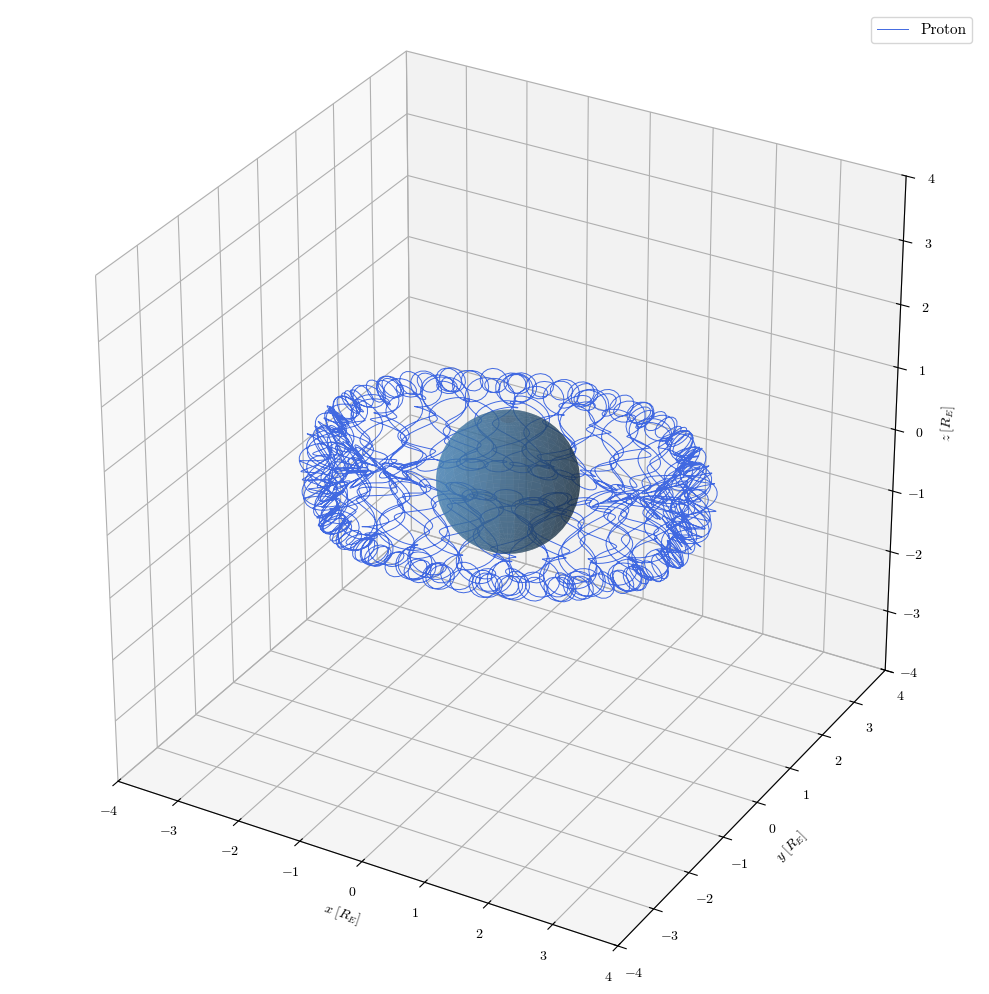

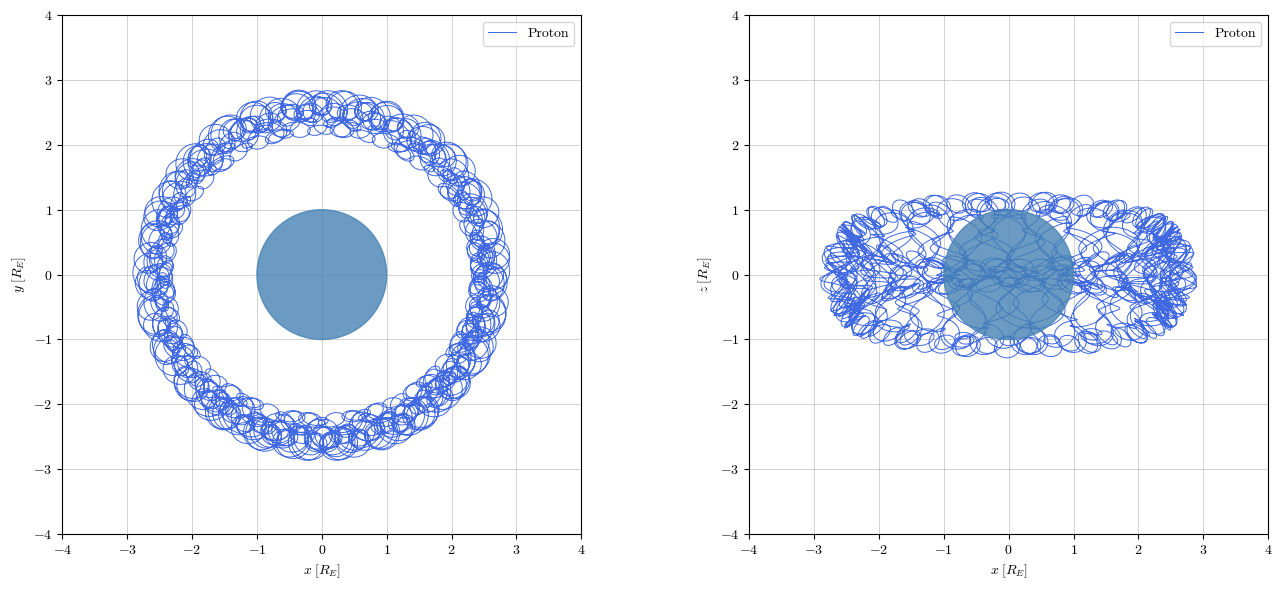

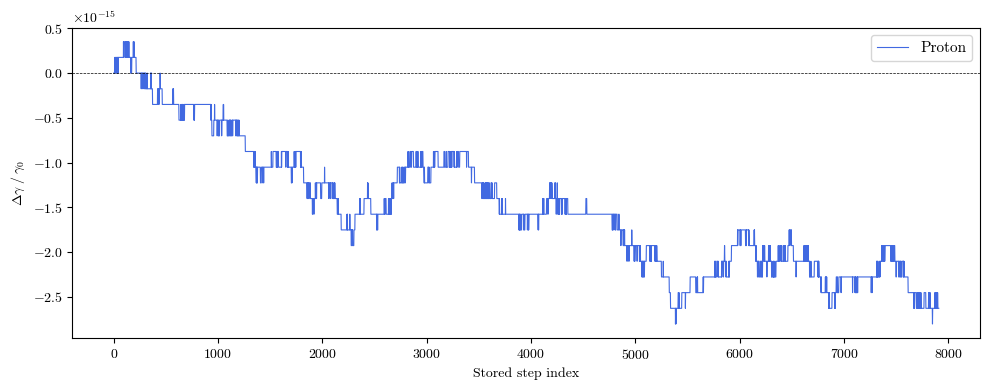

In [9]:
plot_results({'Proton': results['Proton']}, show_plots=True, lim='4')

### Electron — 1 MeV, $L = 4.5\,R_E$

The 1 MeV electron is highly relativistic ($\gamma \approx 2.96$, $\beta \approx 0.94$).
Its much smaller mass yields a cyclotron period ~1800× shorter than the proton at the same
field strength, requiring $dt \sim 10^{-6}$ s. The outer belt at $L=4.5$ has a weaker field
($\sim 20$ nT), giving a larger gyro-radius and a wider drift shell. The electron drifts
**eastward** — opposite to the proton and alpha — because its charge is negative.


Saved: figures/boris_C_trajectories_3D.png
Saved: figures/boris_C_trajectories_2D.png
Saved: figures/boris_C_energy.png


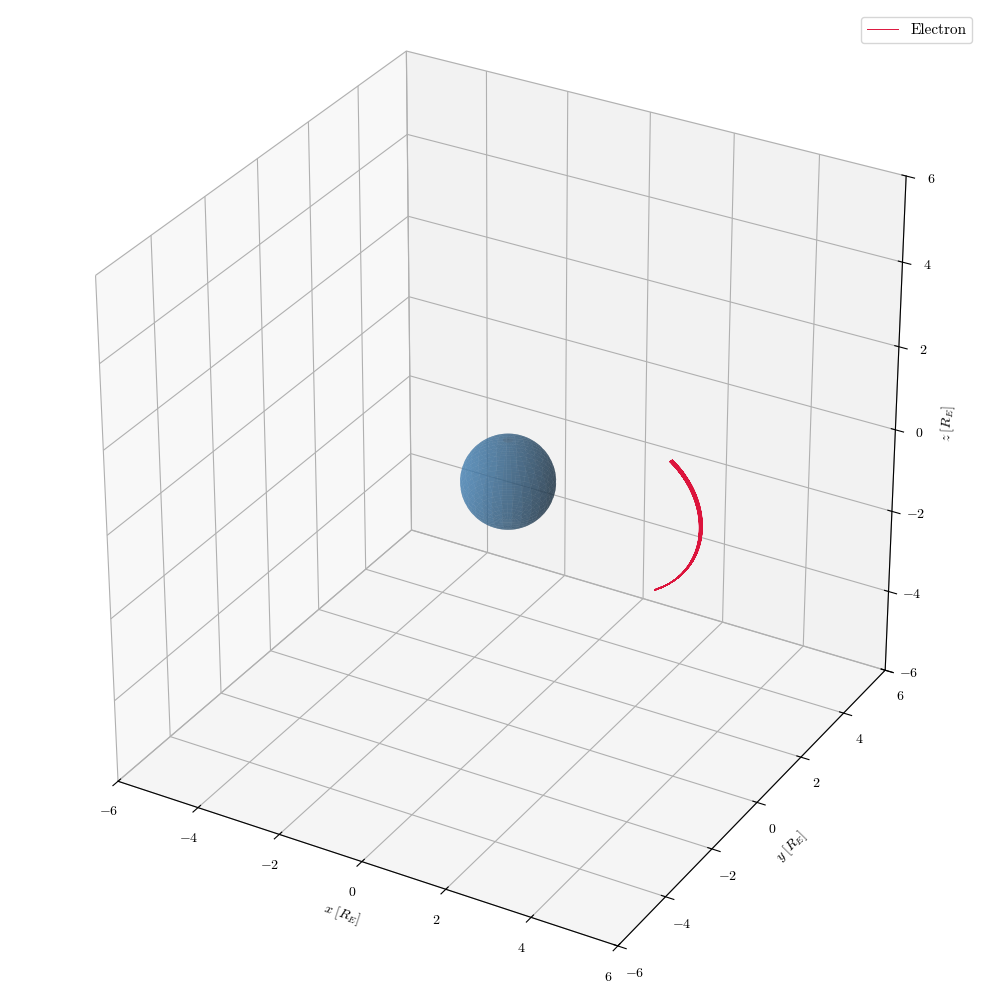

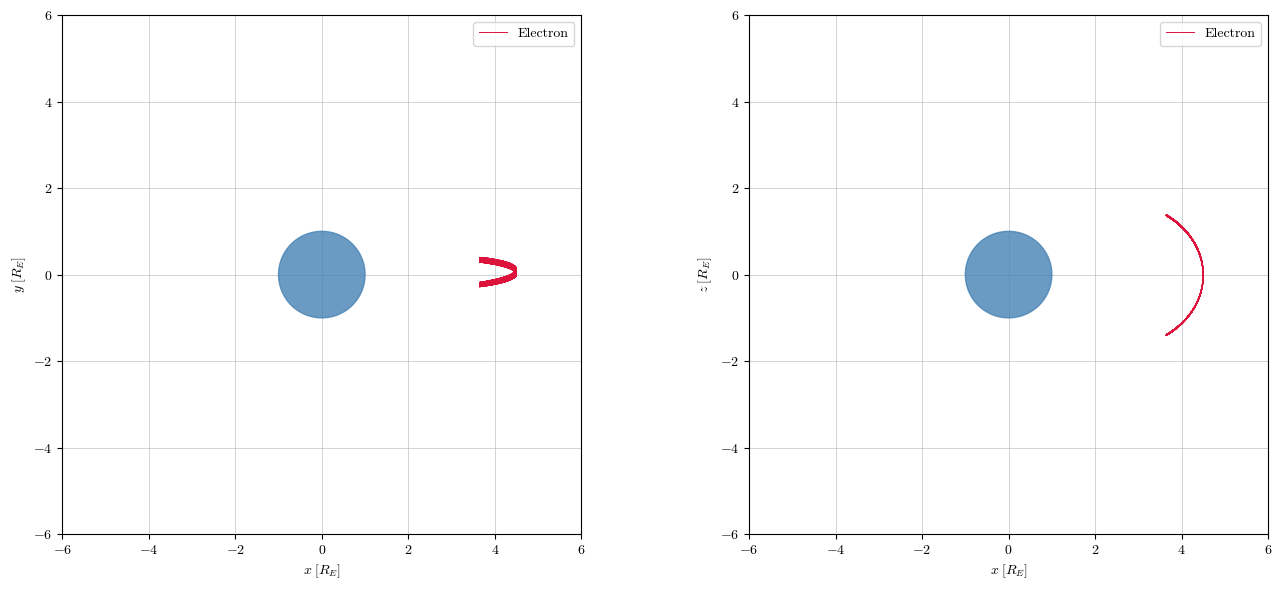

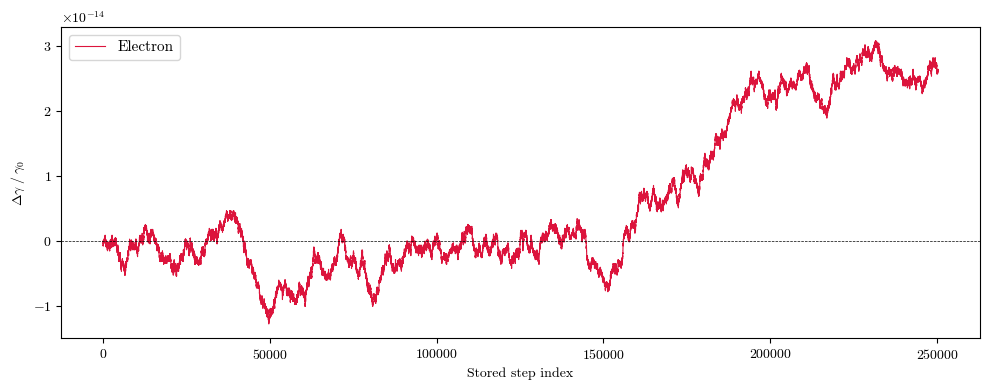

In [10]:
plot_results({'Electron': results['Electron']}, show_plots=True, lim='6')

### Alpha particle — 1 GeV, $L = 2.5\,R_E$

At 1 GeV the alpha is ultra-relativistic ($\gamma \approx 2.51$, $\beta \approx 0.92$).
Its mass is ~4× the proton mass and its charge is $2e$, so the cyclotron period is
$T_c^\alpha = 2\,T_c^p$ — roughly twice as long as the proton's at the same location.
The higher speed means it traverses the bounce path faster than the proton, giving a
shorter $\tau_b$ despite the same L-shell. Like the proton, it drifts **westward**,
and their drift shells overlap in the $xy$ projection.


Saved: figures/boris_C_trajectories_3D.png
Saved: figures/boris_C_trajectories_2D.png
Saved: figures/boris_C_energy.png


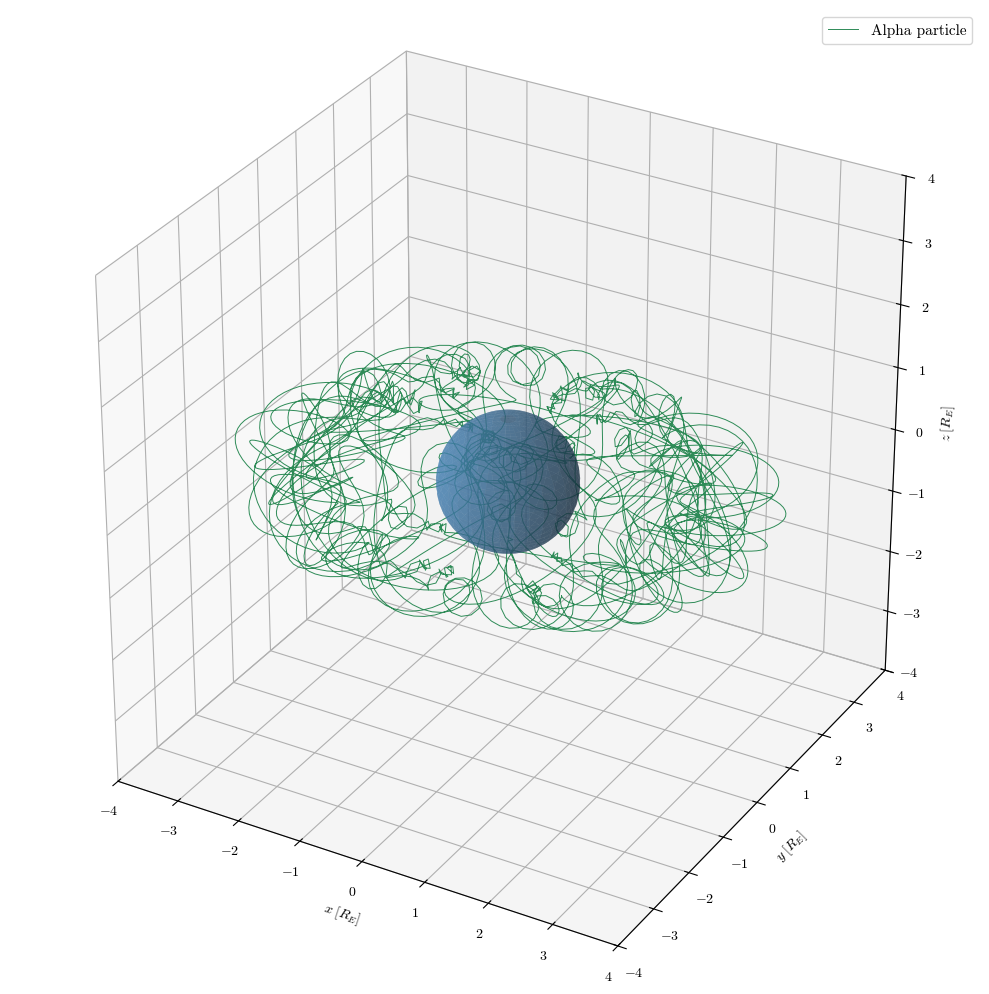

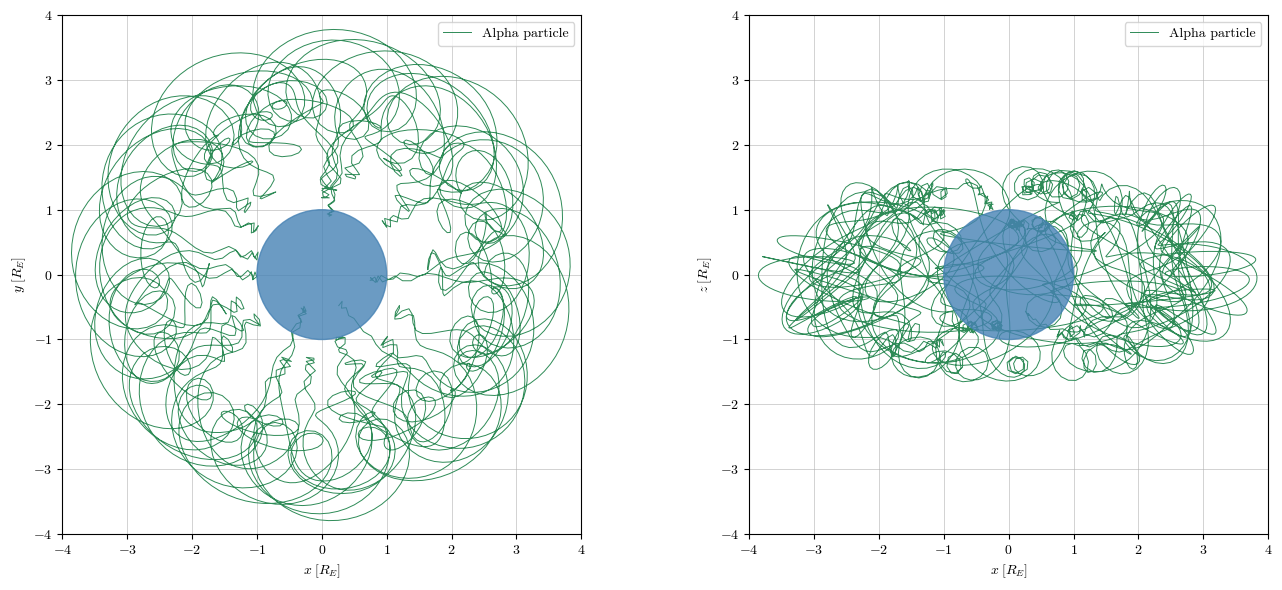

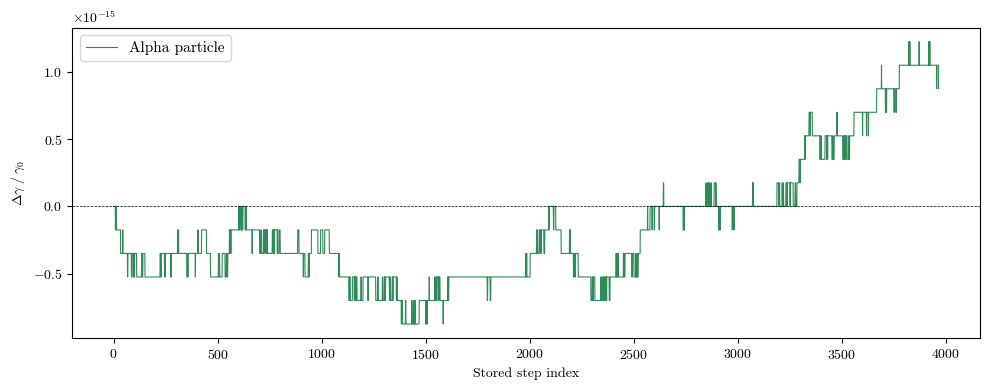

In [11]:
plot_results({'Alpha particle': results['Alpha particle']}, show_plots=True, lim='4')

---
## 4  Summary

### Reading the projections

**Equatorial plane ($xy$):** Arcs trace the **guiding-centre drift shells**. Because
$T_{sim} \ll T_{drift}$, only partial arcs are visible; a full azimuthal drift would close
them into concentric rings. The direction of the arc (east vs. west) reveals the sign of
the charge.

**Meridional plane ($xz$):** The figure-eight pattern is the hallmark of **bounce motion**.
The ribbon width in $z$ is set by the mirror latitude, found from

$$\frac{\sqrt{1+3\sin^2\lambda_m}}{\cos^6\lambda_m} = \frac{1}{\sin^2\alpha_{eq}}$$

Solving numerically for $\alpha_{eq}=60°$ gives $\lambda_m \approx 15°$.

### Loss cone

Particles whose pitch angle falls below the loss cone angle $\alpha_L$ mirror below
Earth's surface and precipitate:

$$\sin^2\alpha_L = \frac{\cos^6\lambda_R}{\sqrt{1+3\sin^2\lambda_R}}, \qquad \cos^2\lambda_R = \frac{1}{L}$$

For $L=2.5$: $\alpha_L \approx 11°$; for $L=4.5$: $\alpha_L \approx 4°$.
All three simulated particles start at $60°$, well above the loss cone.

### Boris-C vs. RK4 — bottom line

The energy error table from Section 2 shows that Boris-C preserves $\gamma$ to near
floating-point precision over the entire simulation, while RK4 accumulates a secular drift.
This difference grows with $N_{steps}$: for the proton and alpha with $\sim 10^5$–$10^6$
steps, RK4's non-symplectic nature is clearly exposed, while Boris-C remains exact to
machine precision — the defining advantage of symplectic integrators in long-duration
particle tracking.